# Laboratorio 4 - Gymnasium

## Instalación y verificación

In [3]:
# Instalación
%pip install "gymnasium[classic-control,toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 729.5 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 698.3 kB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [gymnasium]/4 [gymnasium]

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Versión de Gymnasium:", gym.__version__)

Versión de Gymnasium: 1.3.0


## Instancia del entorno CartPole-v1 

In [5]:
env = gym.make("CartPole-v1")

print("=== Espacio de observación ===")
print("Tipo:", env.observation_space)
print("Shape:", env.observation_space.shape)
print("Límites inferiores:", env.observation_space.low)
print("Límites superiores:", env.observation_space.high)

print("\n=== Espacio de acción ===")
print("Tipo:", env.action_space)
print("Número de acciones:", env.action_space.n)

env.close()

=== Espacio de observación ===
Tipo: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape: (4,)
Límites inferiores: [-4.8               -inf -0.41887903        -inf]
Límites superiores: [4.8               inf 0.41887903        inf]

=== Espacio de acción ===
Tipo: Discrete(2)
Número de acciones: 2


## Agente aleatorio en CartPole-v1 (5 episodios)

In [6]:
def run_random_agent(env_name, n_episodes=5, seed=42):
    """
    Ejecuta un agente que toma acciones aleatorias durante n_episodes episodios.
    Retorna una lista con el número de steps y el return (recompensa total) de cada episodio.
    """
    env = gym.make(env_name)
    steps_por_episodio = []
    returns_por_episodio = []

    for episodio in range(n_episodes):
        observation, info = env.reset(seed=seed + episodio)
        terminated = False
        truncated = False
        steps = 0
        total_reward = 0.0

        while not (terminated or truncated):
            action = env.action_space.sample() 
            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        steps_por_episodio.append(steps)
        returns_por_episodio.append(total_reward)
        print(f"Episodio {episodio + 1}: steps = {steps}, return = {total_reward}")

    env.close()
    return steps_por_episodio, returns_por_episodio


print("=== Agente aleatorio en CartPole-v1 ===")
steps_cartpole, returns_cartpole = run_random_agent("CartPole-v1", n_episodes=5)

=== Agente aleatorio en CartPole-v1 ===
Episodio 1: steps = 29, return = 29.0
Episodio 2: steps = 19, return = 19.0
Episodio 3: steps = 17, return = 17.0
Episodio 4: steps = 40, return = 40.0
Episodio 5: steps = 13, return = 13.0


## Graficar la recompensa

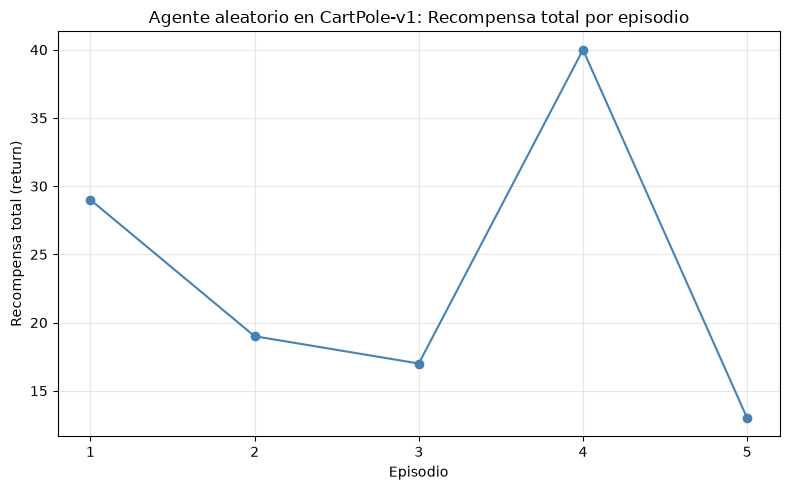

In [7]:
episodios = range(1, len(returns_cartpole) + 1)

plt.figure(figsize=(8, 5))
plt.plot(episodios, returns_cartpole, marker='o', linestyle='-', color='steelblue')
plt.title("Agente aleatorio en CartPole-v1: Recompensa total por episodio")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total (return)")
plt.xticks(episodios)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()